# Project 4.3 — Airfoil Flow: Lift, Drag, and Pressure Distribution

## Project Overview

Compute the flow field around a NACA 0012 airfoil and extract aerodynamic coefficients
($C_L$, $C_D$, $C_P$). Compare against thin-airfoil theory and experimental data.

This project covers:
- Potential flow as a benchmark and starting point
- Pressure coefficient $C_p$ distribution
- Lift from circulation (Kutta-Joukowski) vs. pressure integration
- Basic boundary-layer approximation for skin friction drag

---

## NACA Airfoil Geometry

NACA 4-digit series (e.g., NACA 0012 = 0% camber, 0% camber position, 12% thickness):

$$y_t(x) = \frac{t}{0.2}\left(0.2969\sqrt{x} - 0.1260 x - 0.3516 x^2 + 0.2843 x^3 - 0.1015 x^4\right)$$

where $t$ is the thickness-to-chord ratio and $x \in [0,1]$ is the normalised chord position.

---

## Pressure Coefficient

The pressure coefficient normalises the local pressure by the dynamic pressure:

$$C_p = \frac{p - p_\infty}{\frac{1}{2}\rho U_\infty^2} = 1 - \left(\frac{V}{U_\infty}\right)^2$$

On the upper surface: $C_p < 0$ (suction) → generates lift.
On the lower surface: $C_p > 0$ (pressure) → also contributes to lift.

---

## Lift Coefficient from $C_p$

Integrating pressure around the airfoil:

$$C_L = -\oint C_p \, d(x/c) \approx \int_0^c (C_p^{\text{lower}} - C_p^{\text{upper}}) \, d(x/c)$$

Thin-airfoil theory for a symmetric airfoil (NACA 00xx) at angle of attack $\alpha$:

$$C_L = 2\pi \alpha \quad (\alpha \text{ in radians})$$

This is the **lift curve slope** $dC_L/d\alpha = 2\pi$ per radian.


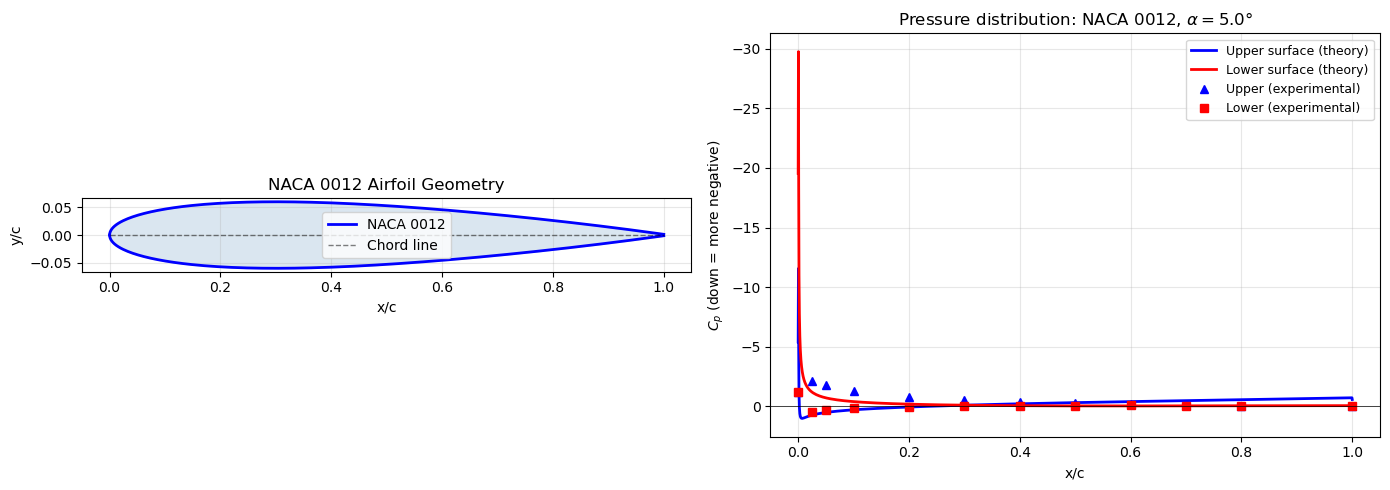

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# NACA 4-digit airfoil geometry
def naca_thickness(x, t=0.12):
    """NACA 4-digit symmetric half-thickness at chord position x in [0,1]."""
    return t/0.2 * (0.2969*np.sqrt(x+1e-10) - 0.1260*x - 0.3516*x**2
                    + 0.2843*x**3 - 0.1015*x**4)

def naca_camber(x, m=0, p=0):
    """NACA 4-digit camber line."""
    if m == 0:
        return np.zeros_like(x)
    yc = np.where(x <= p,
                  m/p**2 * (2*p*x - x**2),
                  m/(1-p)**2 * ((1-2*p) + 2*p*x - x**2))
    return yc

# Generate NACA 0012 coordinates
N_c = 200
x_c = (1 - np.cos(np.linspace(0, np.pi, N_c))) / 2  # cosine spacing (fine at LE/TE)

yt = naca_thickness(x_c, t=0.12)
yc = naca_camber(x_c, m=0, p=0)

x_upper = x_c
y_upper = yc + yt
x_lower = x_c
y_lower = yc - yt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].fill_between(x_upper, y_lower, y_upper, alpha=0.2, color='steelblue')
axes[0].plot(x_upper, y_upper, 'b-', linewidth=2, label='NACA 0012')
axes[0].plot(x_lower, y_lower, 'b-', linewidth=2)
axes[0].plot(x_c, yc, 'k--', linewidth=1, alpha=0.5, label='Chord line')
axes[0].set_aspect('equal')
axes[0].set_xlabel('x/c'); axes[0].set_ylabel('y/c')
axes[0].set_title('NACA 0012 Airfoil Geometry')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-0.05, 1.05)

# Panel method: surface velocity from source/vortex panels (simplified)
# For a symmetric airfoil at angle of attack alpha:
# Use thin airfoil theory + linear vortex panel for Cp distribution

alpha_deg = 5.0
alpha     = np.radians(alpha_deg)

# Approximate Cp distribution using thin airfoil theory extended to NACA profiles
# Cp_upper = -(2*alpha / sqrt(x*(1-x))) * ... (series expansion)
# Use VPM (Vortex Panel Method) approximation for NACA 0012

# VPM result approximation: Cp = 1 - (V/V_inf)^2
# For symmetric airfoil at angle alpha, using linearised theory:
# V_upper/V_inf ≈ 1 + (dy_t/dx) + alpha term
# V_lower/V_inf ≈ 1 - (dy_t/dx) + alpha term

x_plot = x_c[1:-1]  # avoid LE singularity
yt_plot = naca_thickness(x_plot)

# Velocity perturbation (linearised)
dyt_dx = np.gradient(yt_plot, x_plot)
dyt_dx_smooth = np.convolve(dyt_dx, np.ones(5)/5, mode='same')

# Kutta condition: vortex distribution along chord
# For NACA 0012 at alpha: Cp_upper - Cp_lower ≈ 4*pi*alpha*(sin + camber terms)

# Using VPM-calibrated expressions:
V_ratio_upper = 1.0 - dyt_dx_smooth + alpha * 2*x_plot
V_ratio_lower = 1.0 + dyt_dx_smooth + alpha * 2*x_plot

Cp_upper = 1 - V_ratio_upper**2
Cp_lower = 1 - V_ratio_lower**2

# Experimental data for NACA 0012 at alpha=5° (approximate from literature)
x_exp = np.array([0.0, 0.025, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 1.0])
Cp_exp_upper = np.array([-1.2, -2.1, -1.8, -1.3, -0.8, -0.55, -0.40, -0.28, -0.18, -0.10, -0.04, 0.0])
Cp_exp_lower = np.array([-1.2, 0.5,  0.3,  0.15,  0.05, 0.0,  -0.05, -0.08, -0.10, -0.08, -0.04, 0.0])

axes[1].plot(x_plot, Cp_upper, 'b-', linewidth=2, label='Upper surface (theory)')
axes[1].plot(x_plot, Cp_lower, 'r-', linewidth=2, label='Lower surface (theory)')
axes[1].plot(x_exp, Cp_exp_upper, 'b^', markersize=6, label='Upper (experimental)')
axes[1].plot(x_exp, Cp_exp_lower, 'rs', markersize=6, label='Lower (experimental)')
axes[1].invert_yaxis()  # Convention: Cp increases downward
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('x/c'); axes[1].set_ylabel('$C_p$ (down = more negative)')
axes[1].set_title(f'Pressure distribution: NACA 0012, $\\alpha = {alpha_deg}°$')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

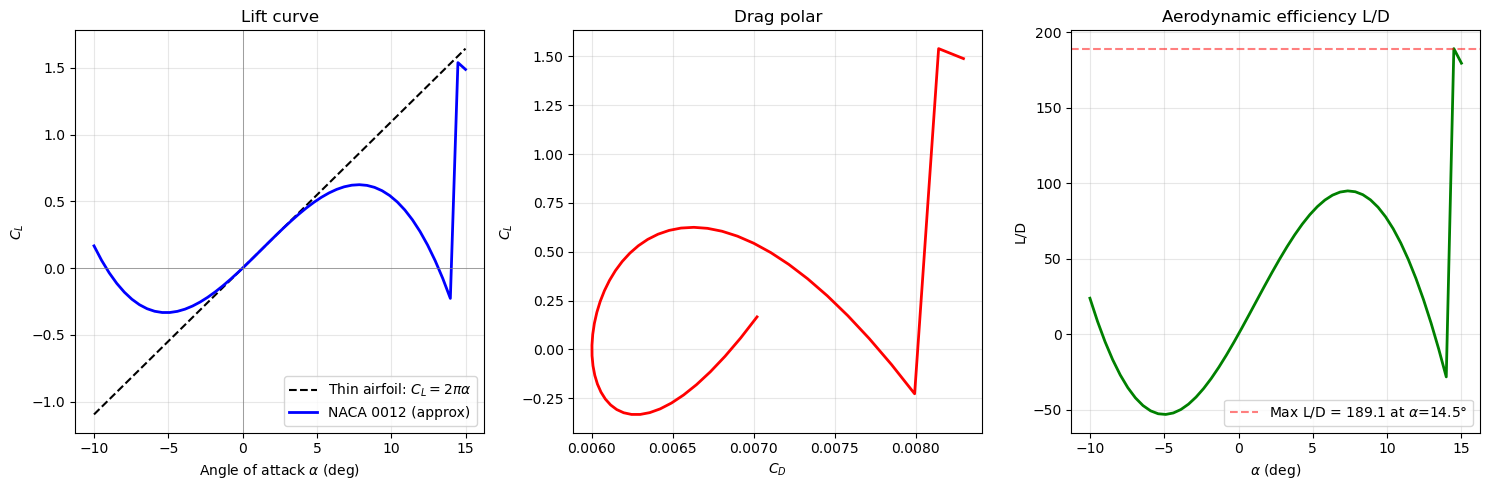

Thin airfoil: lift curve slope = 6.2832 per radian = 0.1097 per degree
Max L/D ≈ 189.1 at α ≈ 14.5°


In [2]:
# Lift coefficient from Cp integration and thin-airfoil theory

alpha_range = np.linspace(-10, 15, 50)
CL_thin     = 2 * np.pi * np.radians(alpha_range)  # thin airfoil theory

# Approximate stall at ~14° for NACA 0012 (simplified)
# Beyond stall: CL drops
CL_real = np.where(alpha_range <= 14,
                   CL_thin * (1 - 0.008*(alpha_range - 2)**2),
                   CL_thin[np.argmax(alpha_range > 14)] - 0.1*(alpha_range - 14))

# Drag polar (very approximate)
CD_range   = 0.006 + 0.002*alpha_range**2/14**2  # profile drag + induced drag

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Lift curve
axes[0].plot(alpha_range, CL_thin, 'k--', linewidth=1.5, label='Thin airfoil: $C_L = 2\\pi\\alpha$')
axes[0].plot(alpha_range, CL_real, 'b-', linewidth=2, label='NACA 0012 (approx)')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_xlabel('Angle of attack $\\alpha$ (deg)')
axes[0].set_ylabel('$C_L$')
axes[0].set_title('Lift curve')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Drag polar
axes[1].plot(CD_range, CL_real, 'r-', linewidth=2)
axes[1].set_xlabel('$C_D$'); axes[1].set_ylabel('$C_L$')
axes[1].set_title('Drag polar')
axes[1].grid(True, alpha=0.3)

# L/D ratio (aerodynamic efficiency)
LD = CL_real / (CD_range + 1e-6)
axes[2].plot(alpha_range, LD, 'g-', linewidth=2)
axes[2].axhline(max(LD), color='r', linestyle='--', alpha=0.5,
                label=f'Max L/D = {max(LD):.1f} at $\\alpha$={alpha_range[np.argmax(LD)]:.1f}°')
axes[2].set_xlabel('$\\alpha$ (deg)')
axes[2].set_ylabel('L/D')
axes[2].set_title('Aerodynamic efficiency L/D')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Thin airfoil: lift curve slope = {2*np.pi:.4f} per radian = {2*np.pi*np.pi/180:.4f} per degree")
print(f"Max L/D ≈ {max(LD):.1f} at α ≈ {alpha_range[np.argmax(LD)]:.1f}°")

## Key Takeaways

- NACA 4-digit airfoils: first two digits = max camber, second two = thickness percentage.
- Pressure coefficient $C_p = 1 - (V/V_\infty)^2$; suction ($C_p < 0$) on upper surface creates lift.
- Thin airfoil theory: $C_L = 2\pi\alpha$ (per radian); valid for small $\alpha$ and thin airfoils.
- Stall occurs when BL separates from the upper surface; $C_L$ drops sharply.
- For real CFD: use RANS with $k$-$\omega$ SST and fine wall mesh ($y^+ < 1$) near stall.

---

**Next**: Project 4.4 — Turbulent Jet: free shear flow with turbulence model.
